## Check temporal evolution of the feature clusters
This code will check the xCorr data:
1. line plots for the 4 categories for the 3 clusters (decide if to drop the 2nd cluster)
2. adjacent matrix and max-time matrix for each cluster

In [1]:
home_dir = '/data/dian';%

addpath(fullfile(home_dir, 'Dropbox/scripts/Stanford/Cohort_Organization'))
addpath(fullfile(home_dir, 'Dropbox/scripts/my_functions'));
addpath(fullfile(home_dir, 'Dropbox/scripts/external'));
addpath(genpath(fullfile(home_dir, 'Dropbox_backup/scripts/external/cbrewer2/cbrewer2')));
addpath(fullfile(home_dir, 'Dropbox/scripts/external/ColorBrewer'));
addpath(fullfile(home_dir, 'Dropbox/scripts/Stanford/lbcn_preproc/visualization'));
addpath(fullfile(home_dir, 'Dropbox/scripts/external/pca_ica'));
addpath(fullfile(home_dir, 'Dropbox/scripts/Stanford/CECS_Pipeline_COPY/CECS_Pipeline/CCEP_pipeline/tools'));
addpath(fullfile(home_dir, 'Dropbox/scripts/JAKE_2/lbcn_preproc/freesurfer'))
addpath(fullfile(home_dir, 'Dropbox/scripts/external/tight_subplot'))
addpath(fullfile(home_dir, 'Dropbox/scripts/Stanford/CECS_Pipeline_COPY/personal_validation'))
addpath(fullfile(home_dir, 'Dropbox/scripts/PlottingTools/pipeline')) % plot_regional_CCEP
addpath(fullfile(home_dir, 'Dropbox/scripts/PlottingTools/Brain_3D')) % plotBrainSurfaceWeight
addpath(genpath(fullfile(home_dir, 'Dropbox/scripts/Stanford/ThalamocoricalLoop-project')))

result_folder = fullfile(home_dir, 'Dropbox/Stanford_Matters/data/THAL/CCEP/results/explore6_xcorr');
prelim_plot_folder = fullfile(home_dir, 'Dropbox/Stanford_Matters/data/THAL/CCEP/Plots/explore6');
input_folder = fullfile(home_dir, 'Dropbox/Stanford_Matters/data/THAL/CCEP/results/explore5_locked');

if ~exist(result_folder); mkdir(result_folder);end
if ~exist(prelim_plot_folder); mkdir(prelim_plot_folder);end

In [2]:
%
%% load stimulation metatable
metaT = readtable(fullfile(input_folder, 'table_CCEPnewpipOutput_wholebrain_anatomical_info_activationRedone2.csv'));
metaT.JP_label_out = ListSortAnatLabel_THAL(metaT.JP_label_out, 1);
metaT.JP_label_in = ListSortAnatLabel_THAL(metaT.JP_label_in, 1);

asublist = unique(metaT.aSubID)';
sublist = unique(metaT.subject)';
%% load UMAP activation 
act = load(fullfile(input_folder, 'umapAct.mat'));
metaT.umapAct = act.umapAct;
%}
% save the updated metaT
%writetable(metaT, fullfile(result_folder,  'table_CCEPnewpipOutput_wholebrain_anatomical_info_activationRedone3.csv'))
%}

%metaT = readtable(fullfile(result_folder, 'table_CCEPnewpipOutput_wholebrain_anatomical_info_activationRedone3.csv'));
metaT.JP_label_out = ListSortAnatLabel_THAL(metaT.JP_label_out, 1);
metaT.JP_label_in = ListSortAnatLabel_THAL(metaT.JP_label_in, 1);
%writetable(metaT, fullfile(result_folder,  'table_CCEPnewpipOutput_wholebrain_anatomical_info_activationRedone3.csv'))

### Check for when the first cluster - first peak arise in each CCEP
COR-ipsi has 39463 trials.
COR-contr has 9415 trials.
THAL-contr has 619 trials.
THAL-ipsi has 5209 trials.
They are concatenated in this order.

In [3]:
n1 = 39463;
n2 = 9415;
n3 = 619;
n4 = 5209;
n5 = 6333; % from SUBCOR
n6 = 6005; % to SUBCOR

In [4]:
cmap1 = [147 181 207; 33 119 184; 20 74 116]/256; %clst1, clst2, clst3 
cmap2 = [147 213 220; 87 195 194; 18 170 156]/256; %clst1, clst2, clst3
cmap3 = [238 162 164; 240 55 82; 166 27 41]/256; %clst1, clst2, clst3 (red--> darker red)
cmap4 = [247 193 115; 242 123 31; 193 101 26]/256; %(orange--> darker orange)

In [ ]:
%plot inline
%% load time xCorr results for each cluster
close; figure('Position', [ 508   656   1400   400]); 

for n_clst = 1:3
    
    tcor = load(fullfile(input_folder, ['timexCorr_all_clst' num2str(n_clst-1) '.mat']));
    time = tcor.time*1000;
    if n_clst==1
        peakRange = [10 75];
    elseif n_clst==2
        peakRange = [75 165];
    elseif n_clst == 3
         peakRange =[165 600];
    end

    % group1
    d = tcor.corMat(1:n1,:);
    mn1 = mean(d, 1, 'omitnan');
    se1 = std(d,1,'omitnan')./sqrt(sum(~isnan(d)));% standard error
    sd1 = std(d,0,'omitnan'); %standard deviation
    [pk1,loc1] = findpeaks(mn1);
    preselect = find(time(loc1)>=peakRange(1) & time(loc1)<peakRange(2));
    if ~isempty(preselect)
        pk1 = pk1(preselect);
        loc1 = loc1(preselect);
    end
    pk1 = pk1(pk1 == max(pk1));
    loc1 = loc1(pk1 == max(pk1));
    
    % group2
    d = tcor.corMat(1+n1:n2+n1,:);
    mn2 = mean(d, 1, 'omitnan');
    se2 = std(d,1,'omitnan')./sqrt(sum(~isnan(d)));% standard error
    sd2 = std(d,0,'omitnan'); %standard deviation
    [pk2,loc2] = findpeaks(mn2);
    preselect = find(time(loc2)>=peakRange(1) & time(loc2)<peakRange(2));
    if ~isempty(preselect)
        pk2 = pk2(preselect);
        loc2 = loc2(preselect);
    end
    pk2 = pk2(pk2 == max(pk2));
    loc2 = loc2(pk2 == max(pk2));
    
    % group3
    d = tcor.corMat(1+n1+n2 : n2+n1+n3,:);
    mn3 = mean(d, 1, 'omitnan');
    se3 = std(d,1,'omitnan')./sqrt(sum(~isnan(d)));% standard error
    sd3 = std(d,0,'omitnan'); %standard deviation
    [pk3,loc3] = findpeaks(mn3);
    preselect = find(time(loc3)>=peakRange(1) & time(loc3)<peakRange(2));
    if ~isempty(preselect)
        pk3 = pk3(preselect);
        loc3 = loc3(preselect);
    end
    pk3 = pk3(pk3 == max(pk3));
    loc3 = loc3(pk3 == max(pk3));
    
    % group4
    d = tcor.corMat(1+n1+n2+n3 : n2+n1+n3+n4,:);
    mn4 = mean(d, 1, 'omitnan');
    se4 = std(d,1,'omitnan')./sqrt(sum(~isnan(d)));% standard error
    sd4 = std(d,0,'omitnan'); %standard deviation
    [pk4,loc4] = findpeaks(mn4);
    preselect = find(time(loc4)>=peakRange(1) & time(loc4)<peakRange(2));
    if ~isempty(preselect)
        pk4 = pk4(preselect);
        loc4 = loc4(preselect);
    end
    pk4 = pk4(pk4 == max(pk4));
    loc4 = loc4(pk4 == max(pk4));

    % plot
    subplot(1,3,n_clst)
    title(['Cluster ' num2str(n_clst)])
    hold on
    
    if n_clst == 1 
        % group1
        shadedErrorBar(time, mn1, se1,...
            'lineProps',{'Color',cmap1(n_clst,:),'LineWidth', 1.5});
        scatter(time(loc1), pk1, 'filled', 'MarkerFaceColor', cmap1(n_clst,:), 'MarkerEdgeColor', cmap1(n_clst,:), 'HandleVisibility','off')
        plot([time(loc1), time(loc1)], [0, pk1], '--', 'Color', cmap1(n_clst,:), 'HandleVisibility','off')
        % group2
        shadedErrorBar(time, mn2, se2,...
            'lineProps',{'Color',cmap2(n_clst,:),'LineWidth', 1.5});
        scatter(time(loc2), pk2, 'filled', 'MarkerFaceColor', cmap2(n_clst,:), 'MarkerEdgeColor', cmap2(n_clst,:), 'HandleVisibility','off')
        plot([time(loc2), time(loc2)], [0, pk2], '--', 'Color', cmap2(n_clst,:), 'HandleVisibility','off')
        % group3
        shadedErrorBar(time, mn4, se4,...
            'lineProps',{'Color',cmap4(n_clst,:),'LineWidth', 1.5});
         scatter(time(loc4), pk4, 'filled', 'MarkerFaceColor', cmap4(n_clst,:), 'MarkerEdgeColor', cmap4(n_clst,:), 'HandleVisibility','off')
         plot([time(loc4), time(loc4)], [0, pk4], '--', 'Color', cmap4(n_clst,:), 'HandleVisibility','off')
        % group4
        shadedErrorBar(time, mn3, se3,...
            'lineProps',{'Color',cmap3(n_clst,:),'LineWidth', 1.5});
        scatter(time(loc3), pk3, 'filled', 'MarkerFaceColor', cmap3(n_clst,:), 'MarkerEdgeColor', cmap3(n_clst,:), 'HandleVisibility','off')
         plot([time(loc3), time(loc3)], [0, pk3], '--', 'Color', cmap3(n_clst,:), 'HandleVisibility','off')
        % legend
        legend({'COR-ipsi','COR-contr','THAL-ipsi','THAL-contr'})
        
    elseif n_clst == 2
        % group1
        shadedErrorBar(time, mn1, se1,...
            'lineProps',{'Color',cmap1(n_clst,:),'LineWidth', 1.5});
        scatter(time(loc1), pk1, 'filled', 'MarkerFaceColor', cmap1(n_clst,:), 'MarkerEdgeColor', cmap1(n_clst,:), 'HandleVisibility','off')
        plot([time(loc1), time(loc1)], [0, pk1], '--', 'Color', cmap1(n_clst,:), 'HandleVisibility','off')
        % group2
        shadedErrorBar(time, mn2, se2,...
            'lineProps',{'Color',cmap2(n_clst,:),'LineWidth', 1.5});
        scatter(time(loc2), pk2, 'filled', 'MarkerFaceColor', cmap2(n_clst,:), 'MarkerEdgeColor', cmap2(n_clst,:), 'HandleVisibility','off')
        plot([time(loc2), time(loc2)], [0, pk2], '--', 'Color', cmap2(n_clst,:), 'HandleVisibility','off')
        % group3
        shadedErrorBar(time, mn4, se4,...
            'lineProps',{'Color',cmap4(n_clst,:),'LineWidth', 1.5});
         scatter(time(loc4), pk4, 'filled', 'MarkerFaceColor', cmap4(n_clst,:), 'MarkerEdgeColor', cmap4(n_clst,:), 'HandleVisibility','off')
         plot([time(loc4), time(loc4)], [0, pk4], '--', 'Color', cmap4(n_clst,:), 'HandleVisibility','off')
        % legend
        legend({'COR-ipsi','COR-contr','THAL-ipsi'})
    elseif n_clst == 3
        % group3
        shadedErrorBar(time, mn4, se4,...
            'lineProps',{'Color',cmap4(n_clst,:),'LineWidth', 1.5});
         scatter(time(loc4), pk4, 'filled', 'MarkerFaceColor', cmap4(n_clst,:), 'MarkerEdgeColor', cmap4(n_clst,:), 'HandleVisibility','off')
         plot([time(loc4), time(loc4)], [0, pk4], '--', 'Color', cmap4(n_clst,:), 'HandleVisibility','off')
        % group4
        shadedErrorBar(time, mn3, se3,...
            'lineProps',{'Color',cmap3(n_clst,:),'LineWidth', 1.5});
        scatter(time(loc3), pk3, 'filled', 'MarkerFaceColor', cmap3(n_clst,:), 'MarkerEdgeColor', cmap3(n_clst,:), 'HandleVisibility','off')
         plot([time(loc3), time(loc3)], [0, pk3], '--', 'Color', cmap3(n_clst,:), 'HandleVisibility','off')
         % legend
        legend({'THAL-ipsi', 'THAL-contr'})
    end
    
    legend boxoff   
    
    xlabel('time(ms)')
    ylabel('similarity')
    xline(0,':', 'HandleVisibility','off')
    if n_clst==1
        xlim([-20,100]) 
    else
        xlim([-20,550]); 
    end
    ylim([0.2, max([mn1,mn2,mn3,mn4])+0.1])
    hold off
    
end
% save plot
exportgraphics(gcf, fullfile(prelim_plot_folder, 'lineplots_timeCorr_clstvstype2.pdf'),'Resolution',300) 

In [5]:
% find the time of max corr
t_maxCor_all = nan(size(metaT,1),3);
p_maxCor_all = nan(size(metaT,1),3);

for n_clst = 1:3
    
    tcor1 = load(fullfile(input_folder, ['timexCorr_all_clst' num2str(n_clst-1) '.mat']));
    tcor2 = load(fullfile(input_folder, ['timexCorr_subcor_clst' num2str(n_clst-1) '.mat']));
    tcor = tcor1;
    tcor.corMat = [tcor1.corMat; tcor2.corMat];
    tcor.filteridx = [tcor1.filteridx; tcor2.filteridx];
    clear tcor1 tcor2
    
    time = tcor.time*1000;
    if n_clst==1
        peakRange = [10 75];
    elseif n_clst==2
        peakRange = [75 165];
    elseif n_clst == 3
        peakRange =[165 600];
    end
    
    d = tcor.corMat;
    mt = nan(size(d,1),1);
    mp = nan(size(d,1),1);
    parfor i = 1:size(d,1) 
        [pk,tm] = findpeaks_clean(d(i,:), peakRange, time); % 6 timepoints = 30ms  
        mt(i) = tm;
        mp(i) = pk;
    end
    t_maxCor_all(tcor.filteridx+1, n_clst) = mt;
    p_maxCor_all(tcor.filteridx+1, n_clst) = mp;
end

Starting parallel pool (parpool) using the 'local' profile ...
Connected to the parallel pool (number of workers: 12).


In [8]:
metaT.time_maxCor_clst1 = t_maxCor_all(:,1);
metaT.peak_maxCor_clst1 = p_maxCor_all(:,1);

metaT.time_maxCor_clst2 = t_maxCor_all(:,2);
metaT.peak_maxCor_clst2 = p_maxCor_all(:,2);

metaT.time_maxCor_clst3 = t_maxCor_all(:,3);
metaT.peak_maxCor_clst3 = p_maxCor_all(:,3);
% save table
writetable(metaT, fullfile(result_folder,  'table_CCEPnewpipOutput_wholebrain_anatomical_info_activationRedone3.csv'))

### Prepare adjacency matrix

In [7]:
%exclude = (ismember(metaT.JP_label_out, {'CLT', 'BG', 'AMY', 'INSULA/LFC'})) | (ismember(metaT.JP_label_in, {'CLT', 'BG', 'AMY', 'INSULA/LFC'}));
exclude = (ismember(metaT.JP_label_out, {'INSULA/LFC'})) | (ismember(metaT.JP_label_in, { 'INSULA/LFC'}));

ipsi  = (metaT.MNIout_coord_1 .* metaT.MNIin_coord_1)>=0;
contr = (metaT.MNIout_coord_1 .* metaT.MNIin_coord_1)<=0;

fromTHAL = ismember(metaT.JP_label_out, {'antTH', 'midTH', 'pstTH'});
fromant = strcmpi(metaT.JP_label_out, 'antTH');
frommid = strcmpi(metaT.JP_label_out, 'midTH');
frompst = strcmpi(metaT.JP_label_out, 'pstTH');

toTHAL = ismember(metaT.JP_label_in, {'antTH', 'midTH', 'pstTH'});
toant = strcmpi(metaT.JP_label_in, 'antTH');
tomid = strcmpi(metaT.JP_label_in, 'midTH');
topst = strcmpi(metaT.JP_label_in, 'pstTH');

isact = (metaT.umapAct == 1);

### Graph of the THAL-ipsi connectivity

In [ ]:

close; figure('Position', [508   656   1583   437])

allWeight = metaT.peak_maxCor_clst1; % [T.peak_maxCor_clst1, T.peak_maxCor_clst2, T.peak_maxCor_clst3]

for i = 1:3
    if i == 1
        filter_boolean = (~exclude) & fromant& ipsi & isact & allWeight>0.2 & ~isnan(allWeight);
    elseif i == 2
        filter_boolean = (~exclude) & frommid& ipsi & isact & allWeight>0.2 & ~isnan(allWeight);
    elseif i == 3
        filter_boolean = (~exclude) & frompst& ipsi & isact & allWeight>0.2 & ~isnan(allWeight);
    end
    T = metaT(filter_boolean,:);

    [~,iu] = unique(strcat(T.JP_label_out, '-', T.JP_label_in));
    fromArea = T.JP_label_out(iu);
    toArea = T.JP_label_in(iu);
    weight = AreaWeightAverage(fromArea, toArea, T.JP_label_out, T.JP_label_in, ...
                               T.peak_maxCor_clst1);
    G = digraph(fromArea, toArea);
    G.Edges.Weight = weight;
   % G.Edges.Weight(isnan(G.Edges.Weight)) = 0.00000001;
    LWidths = 3*G.Edges.Weight/max(G.Edges.Weight);

    % plot
    subplot(1,3,i)
    plot(G,'Layout','force', 'LineWidth',LWidths)
end

### Create standard matrix plot

In [8]:
%clean up metaT
vnames = metaT.Properties.VariableNames;
artPeak_time = 10;
ttpIdx = find(contains(vnames, 'pks_time'));
prefilterIdx =  metaT.eudDist>5 & ...
            ~ismember(metaT.JP_label_in, {'', 'empty', 'NAN', 'NA'}) & ...
            ~ismember(metaT.JP_label_out, {'', 'empty', 'NAN', 'NA'}) & ...
            metaT.sCrossBorder == 0 & metaT.rCrossBorder == 0  &...
         ((sum(table2array(metaT(:, ttpIdx)), 2, 'omitnan')  > artPeak_time) |...  % (...% exclude case when the only peak happens ealier than 10 ms
            (sum(table2array(metaT(:, ttpIdx)), 2, 'omitnan')  ==0) |...
            (isnan(sum(table2array(metaT(:, ttpIdx)), 2, 'omitnan'))));
           % )& ... 
T = metaT(prefilterIdx,:);

In [9]:
hemi_in = repmat('r', size(T,1),1);
hemi_in(T.MNIin_coord_1 < 1) = 'l';

hemi_out = repmat('r', size(T,1),1);
hemi_out(T.MNIout_coord_1 < 1) = 'l';

In [15]:
T.JP_label_in_hemi = strcat(T.JP_label_in, '-', hemi_in);
T.JP_label_out_hemi = strcat(T.JP_label_out, '-', hemi_out);

In [11]:
Area_ordered = {'BG', 'AMY', ... %subcortical, exclude 'CLT'
                'OFC', 'ACC', 'MFC', 'LFC', 'INS',...% frontal % exclude 'FP'
                'TP', 'HPC', 'PHG', 'FG', 'ITG', 'MTG', 'STG', ... % temporal 
                'MCC', 'SM', 'SPL', 'IPL', 'PMC', 'OCC', ... % parietal 
                'antTH', 'midTH', 'pstTH'}'; % thalamus

In [12]:
AL = strcat(Area_ordered,'-l');
AR = strcat(Area_ordered,'-r');
Areas = [AL;AR];

## Activation ratio

In [14]:
cov = nan(length(Areas), length(Areas));
nA = length(Areas); % 
goodTrials = ones(size(T,1),1);
goodTrials(isnan(T.umapAct)) = nan;

parfor n = 1:nA
    fromArea = Areas;
    toArea = repmat(Areas{n}, nA, 1);
    weight = AreaWeightSum(fromArea, toArea, T.JP_label_out_hemi, T.JP_label_in_hemi, ...
                               goodTrials);
    cov(:,n) = weight;
end

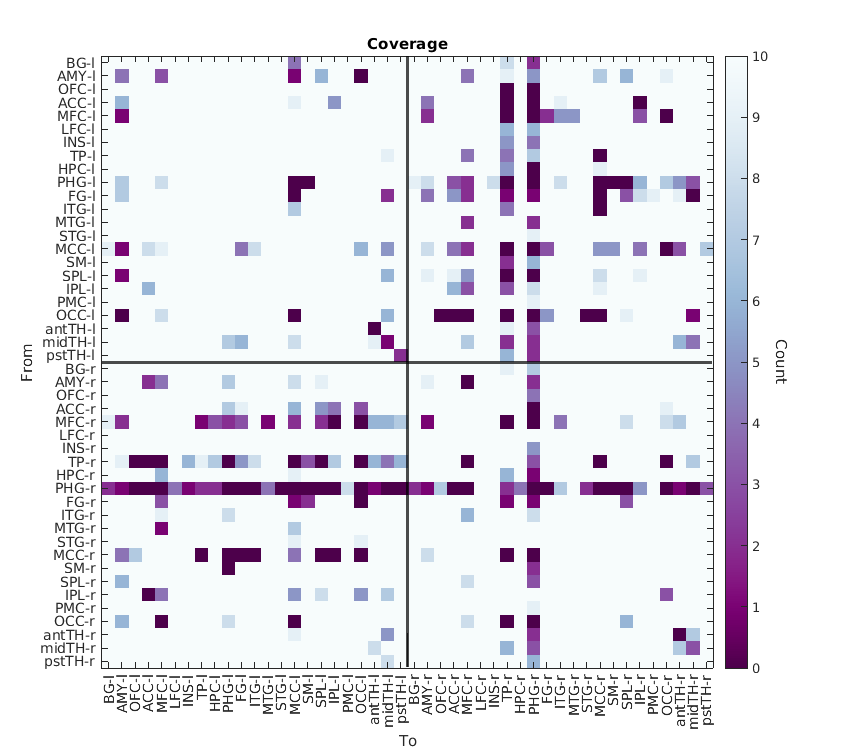

In [134]:
close();
cov0 = cov;
%cov0(cov0<15) = nan;
figure('Position', [508   656   850   750]);
% grey background for nan values
fill([0.5 nA+0.5 nA+0.5 0.5],[0.5 0.5 nA+0.5 nA+0.5], ...
    [0.0 0.8 0.8], 'EdgeColor', 'none'); 
set(gca, 'XTickLabel',[],'XTick',[],'YTickLabel',[],'YTick',[])
xlim([0.5, nA+0.5])
ylim([0.5, nA+0.5])
% plot heatmap
hold on
imagesc(cov0,'AlphaData', ~isnan(cov0)); 
cbar = colorbar; 
ylabel(cbar,'Count','FontSize',11,'Rotation',270)
cbar.Label.VerticalAlignment = "bottom";
%cbar.Position = cbar.Position .* [1.01 1 1 0.9];

colormap(flipud(brewermap([],"BuPu")))
caxis([0,10])
xlabel('To'); ylabel('From')
title('Coverage')
set(gca, ...
    'XTick', 1:nA, 'XTickLabel', Areas,...
    'YTick', 1:nA, 'YTickLabel', Areas,...
    'YDir','reverse')

% add xline and yline
yline(nA/2 + 0.5, 'k', 'LineWidth',1.6)
xline(nA/2 + 0.5, 'k', 'LineWidth',1.6)
hold off
% save plot
figname = 'imagesc_LowerCovCases.pdf';
exportgraphics(gcf, fullfile(prelim_plot_folder, figname ));

In [24]:
actCount = nan(length(Areas), length(Areas));
nA = length(Areas); % 
parfor n = 1:nA
    fromArea = Areas;
    toArea = repmat(Areas{n}, nA, 1);
    weight = AreaWeightSum(fromArea, toArea, T.JP_label_out_hemi, T.JP_label_in_hemi, ...
                            T.umapAct);
    actCount (:,n) = weight;
end

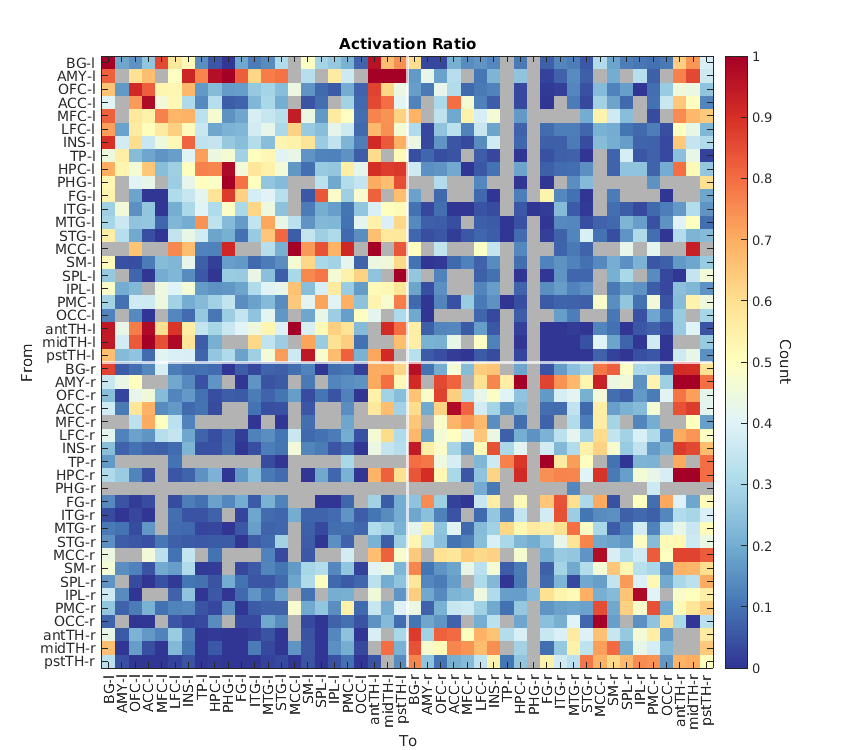

In [27]:
close();
cov0 = cov;
cov0(cov0<10) = nan;
actRat = actCount./cov0;

% plot >>>>>
figure('Position', [508   656   850   750]);
% grey background for nan values
fill([0.5 nA+0.5 nA+0.5 0.5],[0.5 0.5 nA+0.5 nA+0.5], ...
    [0.7 0.7 0.7], 'EdgeColor', 'none'); 
set(gca, 'XTickLabel',[],'XTick',[],'YTickLabel',[],'YTick',[])
xlim([0.5, nA+0.5])
ylim([0.5, nA+0.5])
% plot heatmap
hold on

imagesc(actRat,'AlphaData', ~isnan(actRat)); 
cbar = colorbar; 
ylabel(cbar,'Count','FontSize',11,'Rotation',270)
cbar.Label.VerticalAlignment = "bottom";
%cbar.Position = cbar.Position .* [1.01 1 1 0.9];

cmap = myColors('RdYlBu',[],[],[],0);
cmap = flipud(cmap.cm);
%colormap(flipud(brewermap([],"RdYlBu")))
colormap(cmap)
caxis([0., 1])
xlabel('To'); ylabel('From')
title('Activation Ratio')
set(gca, ...
    'XTick', 1:nA, 'XTickLabel', Areas,...
    'YTick', 1:nA, 'YTickLabel', Areas,...
    'YDir','reverse')
% add xline and yline
yline(nA/2 + 0.5, 'w', 'LineWidth',1.6)
xline(nA/2 + 0.5, 'w', 'LineWidth',1.6)
hold off
% save plot
figname = 'imagesc_UMAPactRatio2.pdf';
exportgraphics(gcf, fullfile(prelim_plot_folder, figname ));

## First wave

In [16]:
peakMat1 = nan(length(Areas), length(Areas));
nA = length(Areas); % 
parfor n = 1:nA
    fromArea = Areas;
    toArea = repmat(Areas{n}, nA, 1);
    weight = AreaWeightAverage(fromArea, toArea, T.JP_label_out_hemi, T.JP_label_in_hemi, ...
                               T.peak_maxCor_clst1 );
    peakMat1(:,n) = weight;
end

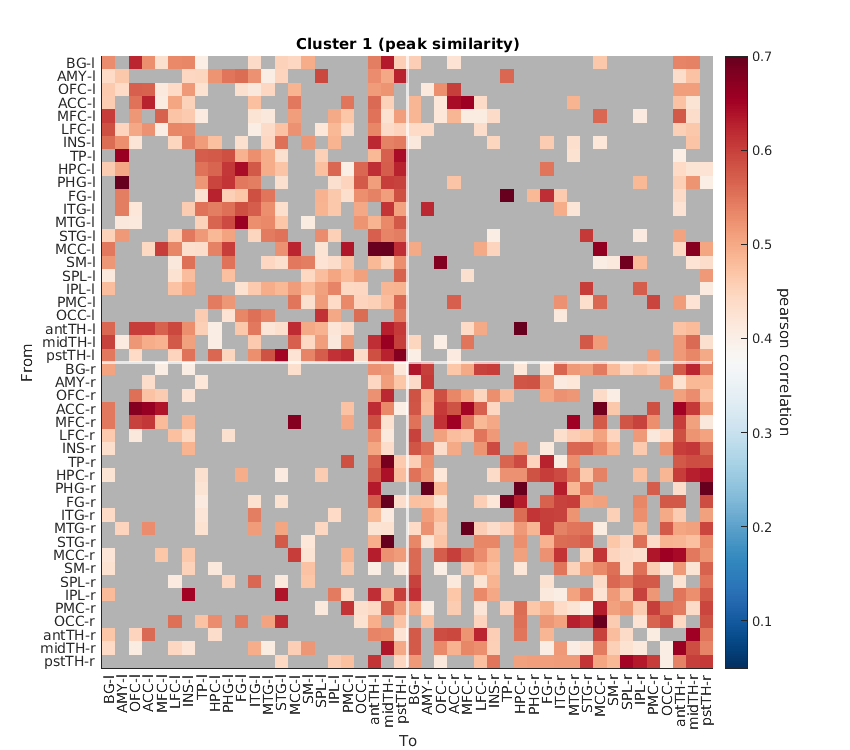

In [47]:
%cmap =  myColors('viridis',[],[],[],0); cmap = cmap.cm;
cmap = flipud(colormap(brewermap([],"RdBu")));;
% threshold over 
imagesc_conn(peakMat1, Areas, 'Cluster 1 (peak similarity)', peakMat1>0.4, cmap, [0.05, 0.7])

% save plot
figname = 'imagesc_clst1_peakSimilarity_thr.pdf';
exportgraphics(gcf, fullfile(prelim_plot_folder, figname ));

In [291]:
timeMat1 = nan(length(Areas), length(Areas));
nA = length(Areas); % 
parfor n = 1:nA
    fromArea = Areas;
    toArea = repmat(Areas{n}, nA, 1);
    weight = AreaWeightAverage(fromArea, toArea, T.JP_label_out_hemi, T.JP_label_in_hemi, ...
                               T.time_maxCor_clst1);
    timeMat1(:,n) = weight;
end

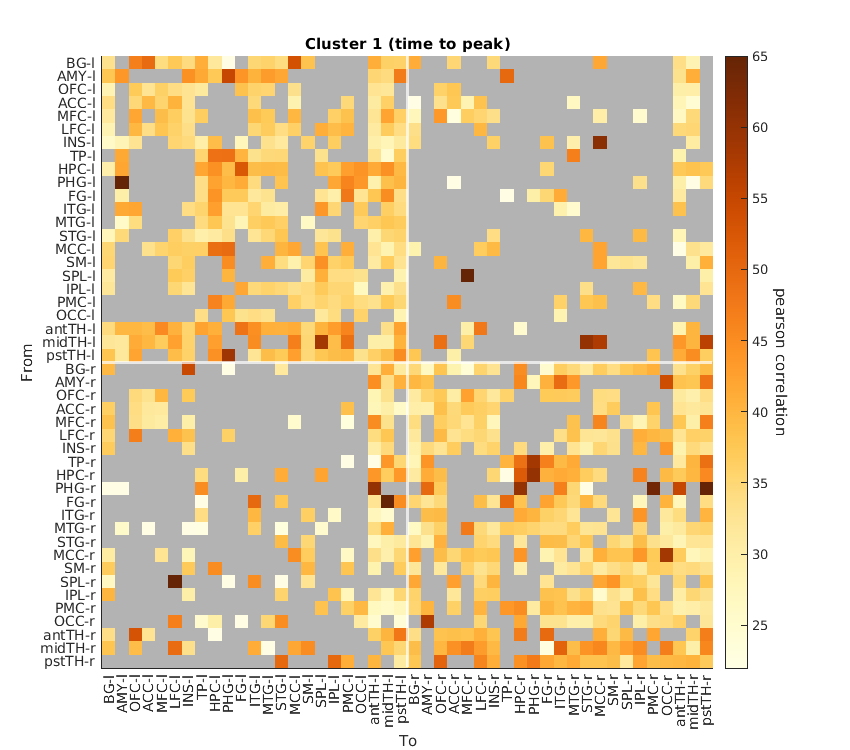

In [292]:
%cmap =  myColors('viridis',[],[],[],0);cmap = flipud(cmap.cm);
cmap = colormap(brewermap([],"YlOrBr"));;
imagesc_conn(timeMat1, Areas, 'Cluster 1 (time to peak)', peakMat1>0.4, cmap, [22,65])
% save plot
figname = 'imagesc_clst1_time2peak.pdf';
exportgraphics(gcf, fullfile(prelim_plot_folder, figname ));

## Second wave

In [41]:
peakMat2 = nan(length(Areas), length(Areas));
nA = length(Areas); % 
parfor n = 1:nA
    fromArea = Areas;
    toArea = repmat(Areas{n}, nA, 1);
    weight = AreaWeightAverage(fromArea, toArea, T.JP_label_out_hemi, T.JP_label_in_hemi, ...
                               T.peak_maxCor_clst2);
    peakMat2(:,n) = weight;
end

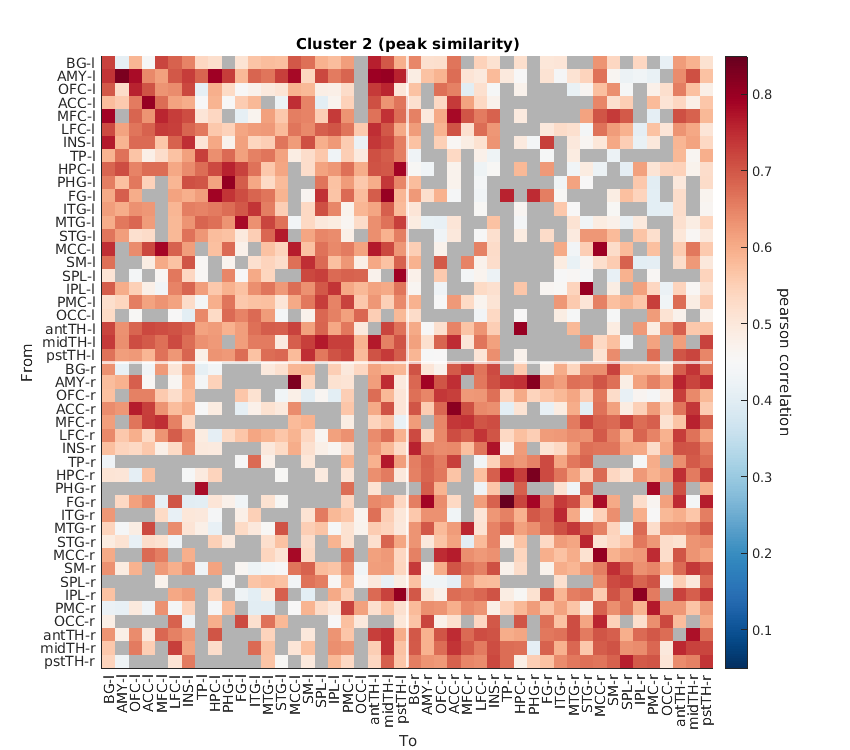

In [49]:
%cmap =  myColors('dawn',[],[],[],0); cmap = cmap.cm;
cmap = flipud(colormap(brewermap([],"RdBu")));;
imagesc_conn(peakMat2, Areas, 'Cluster 2 (peak similarity)', peakMat2>0.4, cmap, [0.05, 0.85])


% save plot
figname = 'imagesc_clst2_peakSimilarity_thr.pdf';
exportgraphics(gcf, fullfile(prelim_plot_folder, figname ));

In [50]:
timeMat2 = nan(length(Areas), length(Areas));
nA = length(Areas); % 
parfor n = 1:nA
    fromArea = Areas;
    toArea = repmat(Areas{n}, nA, 1);
    weight = AreaWeightAverage(fromArea, toArea, T.JP_label_out_hemi, T.JP_label_in_hemi, ...
                               T.time_maxCor_clst2);
    timeMat2(:,n) = weight;
end

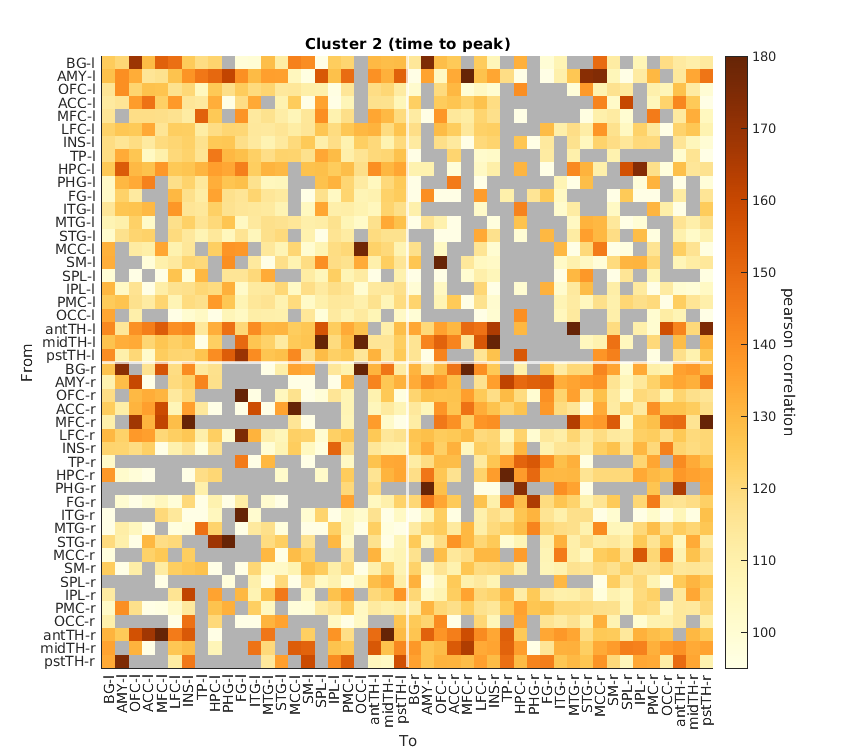

In [296]:
%cmap =  myColors('Spectral',[],[],[],0); cmap = cmap.cm;
cmap = colormap(brewermap([],"YlOrBr"));;
imagesc_conn(timeMat2, Areas, 'Cluster 2 (time to peak)', peakMat2>0.4, cmap, [95 180])
% save plot
figname = 'imagesc_clst2_time2peak.pdf';
exportgraphics(gcf, fullfile(prelim_plot_folder, figname ));

## Third wave

In [51]:
peakMat3 = nan(length(Areas), length(Areas));
nA = length(Areas); % 
parfor n = 1:nA
    fromArea = Areas;
    toArea = repmat(Areas{n}, nA, 1);
    weight = AreaWeightAverage(fromArea, toArea, T.JP_label_out_hemi, T.JP_label_in_hemi, ...
                               T.peak_maxCor_clst3);
    peakMat3(:,n) = weight;
end

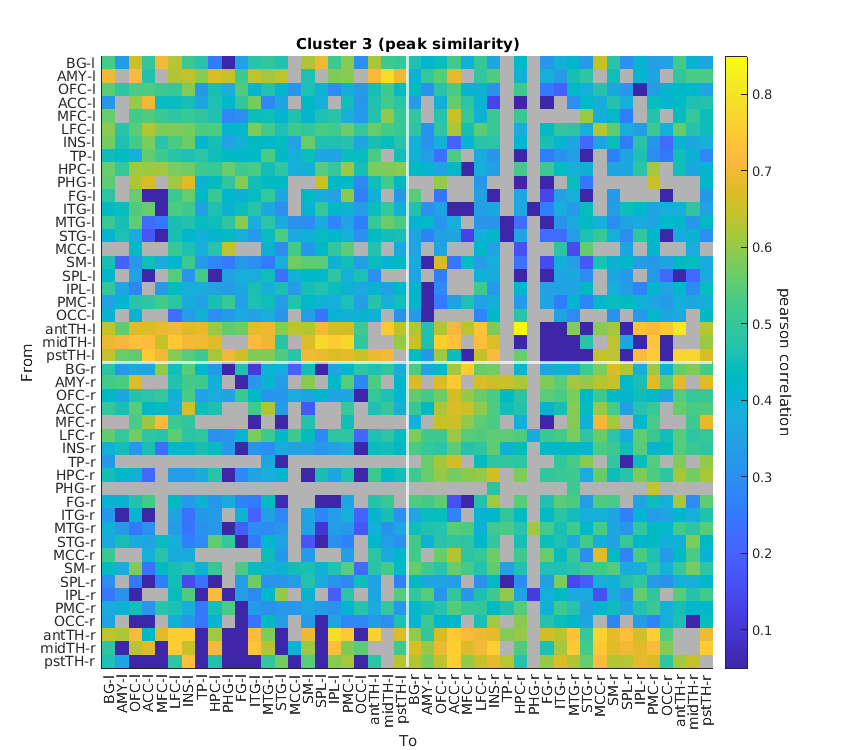

In [54]:
%cmap =  myColors('dawn',[],[],[],0); cmap = cmap.cm;
cmap = parula; %flipud(colormap(brewermap([],"RdBu")));;
imagesc_conn(peakMat3, Areas, 'Cluster 3 (peak similarity)', cov>10, cmap, [0.05, 0.85])


% save plot
figname = 'imagesc_clst3_peakSimilarity2.pdf';
exportgraphics(gcf, fullfile(prelim_plot_folder, figname ));

In [299]:
timeMat3 = nan(length(Areas), length(Areas));
nA = length(Areas); % 
parfor n = 1:nA
    fromArea = Areas;
    toArea = repmat(Areas{n}, nA, 1);
    weight = AreaWeightAverage(fromArea, toArea, T.JP_label_out_hemi, T.JP_label_in_hemi, ...
                               T.time_maxCor_clst3);
    timeMat3(:,n) = weight;
end

In [ ]:
%cmap =  myColors('Spectral',[],[],[],0); cmap = cmap.cm;
cmap = colormap(brewermap([],"YlOrBr"));;
imagesc_conn(timeMat3, Areas, 'Cluster 3 (time to peak)', peakMat3>0.5, cmap, [165 300])
% save plot
figname = 'imagesc_clst3_time2peak.pdf';
exportgraphics(gcf, fullfile(prelim_plot_folder, figname ));